# Inspection of the data: labels and features distributions, correlations, etc.

In [25]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
from matplotlib.ticker import PercentFormatter
from matplotlib.colors import LogNorm

In [26]:
df = pd.read_parquet('./classification_ring/data/processed/train.parquet')


pair_cols = [
    "pdb_id",
    "s_ch", "s_resi", "s_ins", "s_resn",
    "t_ch", "t_resi", "t_ins", "t_resn"
]

label_cols = ['HBOND', 'VDW', 'IONIC', 'PIPISTACK', 'PICATION', 'SSBOND', 'PIHBOND']

#Numerical features
num_features = [
    's_rsa', 's_phi', 's_psi', 's_a1', 's_a2', 's_a3', 's_a4', 's_a5',
    #'s_3di_state',
    't_rsa', 't_phi', 't_psi', 't_a1', 't_a2', 't_a3', 't_a4', 't_a5',
    #'t_3di_state'
]

#Categorical features
cat_features = [
    's_ss8', 's_3di_letter',
    't_ss8', 't_3di_letter'
]



feature_cols = num_features + cat_features

X = df[feature_cols]
Y = df[label_cols]


,label,count,prevalence
6,HBOND,727034,0.727701
5,VDW,506568,0.507033
4,PIPISTACK,26619,0.026643
3,IONIC,24650,0.024673
2,PICATION,6085,0.006091
1,SSBOND,1345,0.001346
0,PIHBOND,1322,0.001323


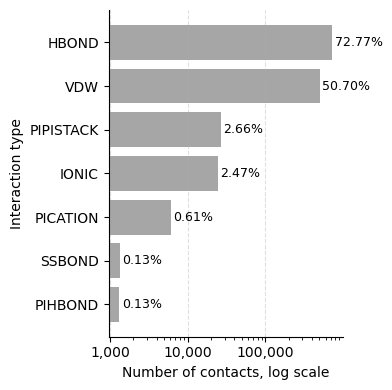

In [27]:


# Count positive examples for each label
label_counts = df[label_cols].sum().sort_values(ascending=True)

# Convert to prevalence
label_prevalence = label_counts / len(df)

label_summary_df = pd.DataFrame({
    "label": label_counts.index,
    "count": label_counts.values,
    "prevalence": label_prevalence.values
}).sort_values("count", ascending=False)

display(label_summary_df)

# Report-quality horizontal bar plot
fig, ax = plt.subplots(figsize=(4, 4))

ax.barh(label_counts.index, label_counts.values, color = "grey", alpha=0.7)

ax.set_xscale("log")
ax.set_xlabel("Number of contacts, log scale")
ax.set_ylabel("Interaction type")
#ax.set_title("Label counts across interaction types")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{int(x):,}" if x >= 1 else "")
)

ax.grid(axis="x", linestyle="--", alpha=0.4)



# Annotate each bar with prevalence

for label, count in label_counts.items():
    prevalence = label_prevalence.loc[label]
    ax.text(
        count * 1.08,
        label,
        f"{prevalence:.2%}",
        va="center",
        fontsize=9
    )

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
os.makedirs("report_figures", exist_ok=True)
fig.savefig(
    "report_figures/label_frequency.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

--- 
## Labels

**Labels overlap matrix (raw counts):**

In [28]:
# label frequency (fraction of samples with label present)
frequencies = Y.sum(axis =0) / Y.shape[0]
frequencies_df = pd.DataFrame({'label': frequencies.index, 'frequency': frequencies.values})
display(frequencies_df)

,label,frequency
0,HBOND,0.727701
1,VDW,0.507033
2,IONIC,0.024673
3,PIPISTACK,0.026643
4,PICATION,0.006091
5,SSBOND,0.001346
6,PIHBOND,0.001323


In [29]:
overlap_counts = Y.T @ Y

display(overlap_counts)

,HBOND,VDW,IONIC,PIPISTACK,PICATION,SSBOND,PIHBOND
HBOND,727034,249077,22851,7168,1512,46,351
VDW,249077,506568,13150,12666,3219,879,799
IONIC,22851,13150,24650,0,0,0,0
PIPISTACK,7168,12666,0,26619,0,0,295
PICATION,1512,3219,0,0,6085,0,259
SSBOND,46,879,0,0,0,1345,0
PIHBOND,351,799,0,295,259,0,1322


**Label overlap matrix (conditional)**:

Of the samples that have the row label, what fraction also have the column label?

So, for example, the entry (HBOND, VDW) represents the fraction of HBONDs that are also VDW

In [30]:
label_totals = Y.sum(axis=0)

conditional_overlap = overlap_counts.div(label_totals, axis=0)

display(conditional_overlap)

,HBOND,VDW,IONIC,PIPISTACK,PICATION,SSBOND,PIHBOND
HBOND,1.000000,0.342593,0.031430,0.009859,0.002080,0.000063,0.000483
VDW,0.491695,1.000000,0.025959,0.025004,0.006355,0.001735,0.001577
IONIC,0.927018,0.533469,1.000000,0.000000,0.000000,0.000000,0.000000
PIPISTACK,0.269281,0.475826,0.000000,1.000000,0.000000,0.000000,0.011082
PICATION,0.248480,0.529006,0.000000,0.000000,1.000000,0.000000,0.042564
SSBOND,0.034201,0.653532,0.000000,0.000000,0.000000,1.000000,0.000000
PIHBOND,0.265507,0.604387,0.000000,0.223147,0.195915,0.000000,1.000000


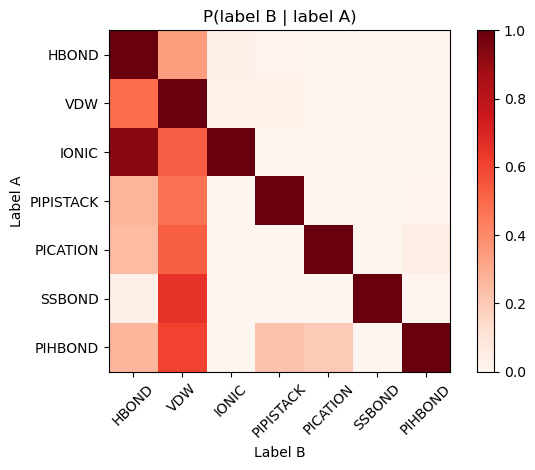

In [31]:
plt.imshow(conditional_overlap, cmap='Reds', vmin=0, vmax=1)
plt.colorbar()
plt.xticks(ticks=np.arange(len(label_cols)), labels=label_cols, rotation=45)
plt.yticks(ticks=np.arange(len(label_cols)), labels=label_cols)
plt.title('P(label B | label A)')
plt.xlabel('Label B')
plt.ylabel('Label A')
plt.tight_layout()
plt.show()

Observations:

- VDW label is very generic: P(VDW | other class label) is $\geq 40\%$ for all the other labels. Roughly half of the samples that receive some label, also receive the VDW label in addition.

- Most of the samples ($\sim 90\%$) labeled as IONIC also get labelled as HBOND. Biologically, this also makes sense. Ionic interactions, or salt bridges, often occur between charged donor/acceptor groups. This means IONIC is highly nested inside HBOND in your labeling scheme. The reverse is much smaller: only about 3.1% of hydrogen bonds are ionic, because many hydrogen bonds are neutral.

- PIPISTACK, PICATION also get assigned in addition to PIHBOND.



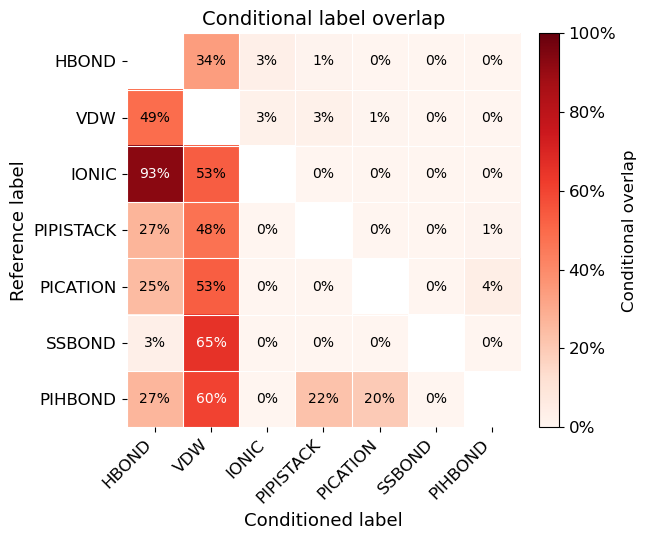

In [32]:
# Font sizes, approximately 20% larger than typical defaults
BASE_SIZE = 12
TITLE_SIZE = 14
LABEL_SIZE = 13
TICK_SIZE = 12
ANNOT_SIZE = 10
CBAR_SIZE = 12

# Ensure row/column order is consistent
plot_matrix = conditional_overlap.loc[label_cols, label_cols].astype(float).copy()

# Mask diagonal, since P(A | A) = 1 by definition
for label in label_cols:
    plot_matrix.loc[label, label] = np.nan

fig, ax = plt.subplots(figsize=(6.5, 5.5))

im = ax.imshow(
    plot_matrix,
    cmap="Reds",
    vmin=0,
    vmax=1
)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Conditional overlap", fontsize=CBAR_SIZE)
cbar.ax.tick_params(labelsize=TICK_SIZE)
cbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

ax.set_xticks(np.arange(len(label_cols)))
ax.set_yticks(np.arange(len(label_cols)))
ax.set_xticklabels(label_cols, rotation=45, ha="right", fontsize=TICK_SIZE)
ax.set_yticklabels(label_cols, fontsize=TICK_SIZE)

ax.set_xlabel("Conditioned label", fontsize=LABEL_SIZE)
ax.set_ylabel("Reference label", fontsize=LABEL_SIZE)
ax.set_title("Conditional label overlap", fontsize=TITLE_SIZE)

for i in range(len(label_cols)):
    for j in range(len(label_cols)):
        value = plot_matrix.iloc[i, j]
        if np.isfinite(value):
            ax.text(
                j,
                i,
                f"{value:.0%}",
                ha="center",
                va="center",
                fontsize=ANNOT_SIZE,
                color="black" if value < 0.6 else "white"
            )

ax.set_xticks(np.arange(-0.5, len(label_cols), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(label_cols), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=0.8)
ax.tick_params(which="minor", bottom=False, left=False)

for spine in ax.spines.values():
    spine.set_visible(False)

fig.tight_layout()

fig.savefig(
    "conditional_label_overlap.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Missing values in features - statistics

In [33]:
features_df = df[feature_cols].copy()
features_df.head()

missing_values_df = features_df.isna().mean().sort_values(ascending=False).head(20) * 100
print("\nMissing values:")
print(missing_values_df)


Missing values:
t_3di_letter    1.544116
s_3di_letter    1.298391
t_psi           0.753891
s_phi           0.592543
s_psi           0.244524
t_phi           0.185070
t_rsa           0.000300
s_a1            0.000000
t_a3            0.000000
t_ss8           0.000000
s_ss8           0.000000
t_a5            0.000000
t_a4            0.000000
t_a1            0.000000
t_a2            0.000000
s_a2            0.000000
s_a5            0.000000
s_a4            0.000000
s_a3            0.000000
s_rsa           0.000000
dtype: float64


In [34]:
latex_missing_table = missing_values_df.to_latex(
    index=True,
    escape=True,
    column_format="lrr",
    caption="Missing feature values across input features.",
    label="tab:missing_features"
)

print(latex_missing_table)

\begin{table}
\caption{Missing feature values across input features.}
\label{tab:missing_features}
\begin{tabular}{lrr}
\toprule
 & 0 \\
\midrule
t\_3di\_letter & 1.544116 \\
s\_3di\_letter & 1.298391 \\
t\_psi & 0.753891 \\
s\_phi & 0.592543 \\
s\_psi & 0.244524 \\
t\_phi & 0.185070 \\
t\_rsa & 0.000300 \\
s\_a1 & 0.000000 \\
t\_a3 & 0.000000 \\
t\_ss8 & 0.000000 \\
s\_ss8 & 0.000000 \\
t\_a5 & 0.000000 \\
t\_a4 & 0.000000 \\
t\_a1 & 0.000000 \\
t\_a2 & 0.000000 \\
s\_a2 & 0.000000 \\
s\_a5 & 0.000000 \\
s\_a4 & 0.000000 \\
s\_a3 & 0.000000 \\
s\_rsa & 0.000000 \\
\bottomrule
\end{tabular}
\end{table}



In [35]:
print("Unique values of cathegorical features:")



for col in cat_features:
    unique_count = features_df[col].nunique() # doesnt inlude NaN by default
    print(f"{col}: {unique_count} unique values")
    print(f"Unique values for {col}: {features_df[col].unique()}")
    print("\n\n")

Unique values of cathegorical features:
s_ss8: 9 unique values
Unique values for s_ss8: <ArrowStringArray>
['H', '-', 'T', 'G', 'S', 'E', 'B', 'P', 'I']
Length: 9, dtype: str



s_3di_letter: 20 unique values
Unique values for s_3di_letter: <ArrowStringArray>
['P', 'A', 'R', 'B', 'C', 'D', 'N', 'M', 'Q', 'G', 'F', 'J', 'S', 'E', 'L',
 'T', 'I', 'H', 'O', nan, 'K']
Length: 21, dtype: str



t_ss8: 9 unique values
Unique values for t_ss8: <ArrowStringArray>
['-', 'G', 'H', 'E', 'S', 'T', 'P', 'B', 'I']
Length: 9, dtype: str



t_3di_letter: 20 unique values
Unique values for t_3di_letter: <ArrowStringArray>
['F', 'B', 'R', 'N', 'C', 'L', 'P', 'M', 'J', 'Q', 'O', 'E', 'G', 'H', 'I',
 'K', 'T', 'A', 'S', nan, 'D']
Length: 21, dtype: str





## Pair frequencies Histograms for the categorical features

In [36]:
def plot_categorical_pair_heatmap(
    df,
    col1,
    col2,
    title,
    xlabel,
    ylabel,
    filename,
    normalize=True,
    annotate=True
):
    
    pair_counts = pd.crosstab(
        df[col1],#.fillna("Missing"),
        df[col2]#.fillna("Missing")
    )

    # Enforce same ordering if both columns have the same categories
    categories = sorted(
        set(pair_counts.index).union(set(pair_counts.columns)),
        key=lambda x: str(x)
    )

    pair_counts = pair_counts.reindex(index=categories, columns=categories, fill_value=0)

    if normalize:
        plot_df = 100 * pair_counts / pair_counts.values.sum()
        cbar_label = "Frequency (%)"
    else:
        plot_df = pair_counts
        cbar_label = "Count"

    fig_width = max(5.5, 0.45 * len(categories))
    fig_height = max(5.0, 0.45 * len(categories))

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    im = ax.imshow(plot_df.values, aspect="auto", cmap="Reds")

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label)

    ax.set_xticks(np.arange(len(categories)))
    ax.set_yticks(np.arange(len(categories)))
    ax.set_xticklabels(categories, rotation=45, ha="right")
    ax.set_yticklabels(categories)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    if annotate:
        for i in range(plot_df.shape[0]):
            for j in range(plot_df.shape[1]):
                value = plot_df.iloc[i, j]

                if normalize:
                    text = f"{value:.1f}%" if value >= 0.5 else ""
                else:
                    text = f"{int(value)}" if value > 0 else ""

                if text:
                    ax.text(
                        j,
                        i,
                        text,
                        ha="center",
                        va="center",
                        fontsize=8
                    )

    ax.set_xticks(np.arange(-0.5, len(categories), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(categories), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.8)
    ax.tick_params(which="minor", bottom=False, left=False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    fig.tight_layout()
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

    return pair_counts, plot_df

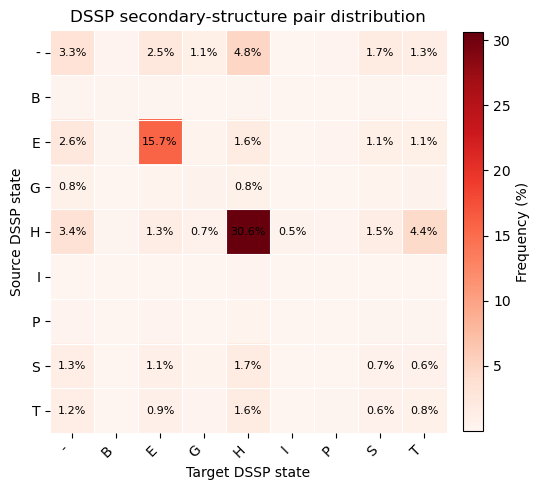

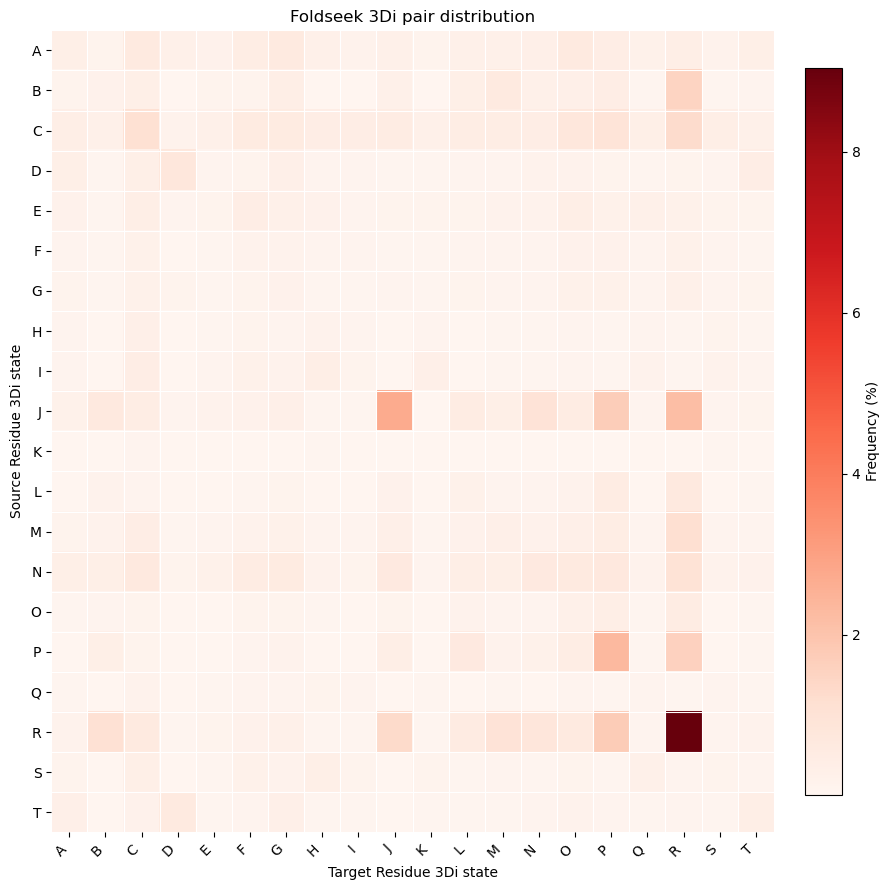

In [37]:
dssp_counts, dssp_percentages = plot_categorical_pair_heatmap(
    df=df,
    col1="s_ss8",
    col2="t_ss8",
    title="DSSP secondary-structure pair distribution",
    xlabel="Target DSSP state",
    ylabel="Source DSSP state",
    filename="report_figures/dssp_pair_distribution.pdf",
    normalize=True,
    annotate=True
)


di_counts, di_percentages = plot_categorical_pair_heatmap(
    df=df,
    col1="s_3di_letter",
    col2="t_3di_letter",
    title="Foldseek 3Di pair distribution",
    xlabel="Target Residue 3Di state",
    ylabel="Source Residue 3Di state",
    filename="report_figures/3di_pair_distribution.pdf",
    normalize=True,
    annotate=False
)

## Marginal frequencies histograms for FoldSeek 3D

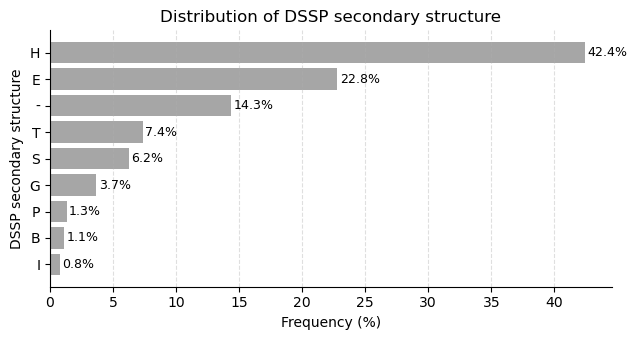

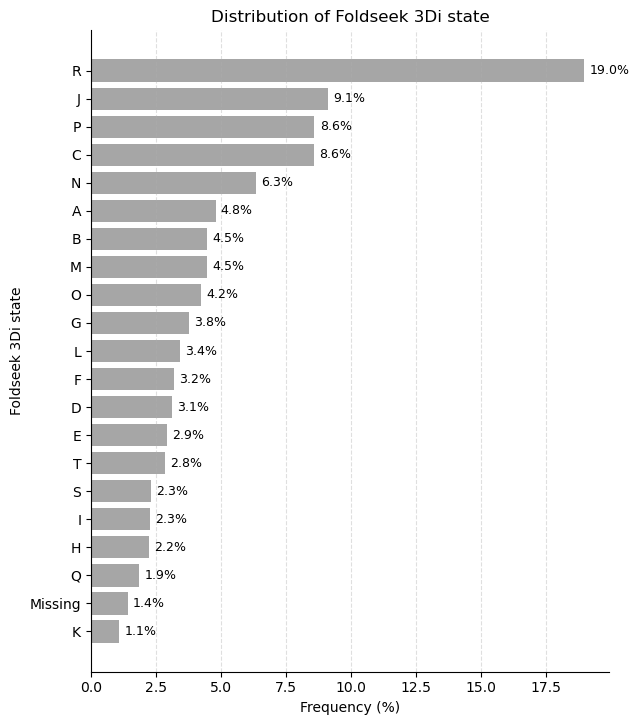

In [38]:
pooled_categorical_features = {
    "DSSP secondary structure": ["s_ss8", "t_ss8"],
    "Foldseek 3Di state": ["s_3di_letter", "t_3di_letter"]
}

for feature_name, cols in pooled_categorical_features.items():
    
    pooled_values = (
        pd.concat([df[col] for col in cols], axis=0)
        .fillna("Missing")
    )
    
    value_counts = (
        pooled_values
        .value_counts(normalize=True)
        .mul(100)
        .sort_values(ascending=True)
    )
    
    fig_height = max(3.5, 0.35 * len(value_counts))
    fig, ax = plt.subplots(figsize=(6.5, fig_height))
    
    ax.barh(value_counts.index.astype(str), value_counts.values, color="grey", alpha=0.7)
    
    ax.set_xlabel("Frequency (%)")
    ax.set_ylabel(feature_name)
    ax.set_title(f"Distribution of {feature_name}")
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    
    for label, value in value_counts.items():
        ax.text(
            value + 0.2,
            str(label),
            f"{value:.1f}%",
            va="center",
            fontsize=9
        )
    
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    
    fig.tight_layout()
    filename = feature_name.lower().replace(" ", "_").replace("3di", "3di")
    fig.savefig(f"report_figures/distribution_{filename}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

### Pair frequencies histograms for the numerical features

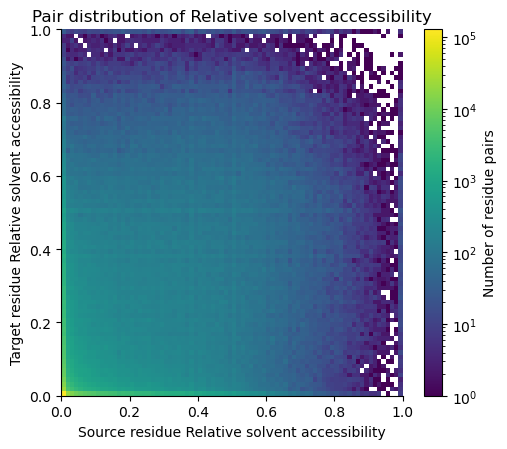

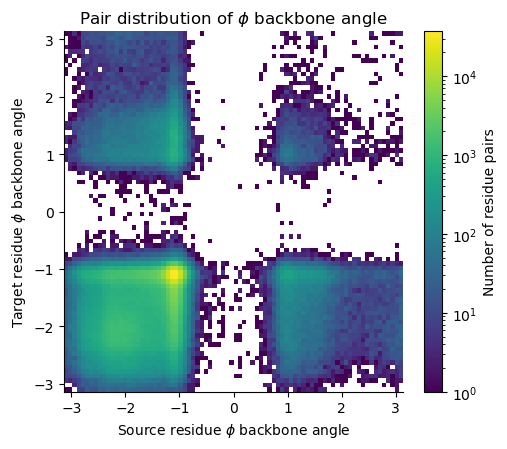

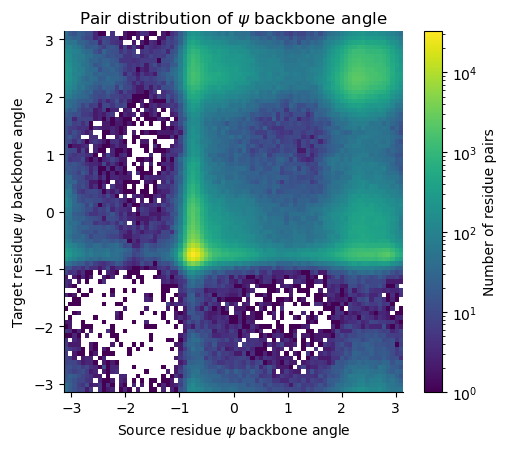

In [39]:
feature_pairs = [
    ("s_rsa", "t_rsa", "Relative solvent accessibility"),
    ("s_phi", "t_phi", r"$\phi$ backbone angle"),
    ("s_psi", "t_psi", r"$\psi$ backbone angle")
]


def plot_2d_histogram(
    df,
    x_col,
    y_col,
    feature_label,
    filename,
    bins=80,
    use_log_scale=True,
):
    plot_df = df[[x_col, y_col]].dropna()

    x = plot_df[x_col].values
    y = plot_df[y_col].values

    fig, ax = plt.subplots(figsize=(5.2, 4.6))

    if use_log_scale:
        hist = ax.hist2d(
            x,
            y,
            bins=bins,
            norm=LogNorm()
        )
    else:
        hist = ax.hist2d(
            x,
            y,
            bins=bins
        )

    cbar = fig.colorbar(hist[3], ax=ax)
    cbar.set_label("Number of residue pairs")

    ax.set_xlabel(f"Source residue {feature_label}")
    ax.set_ylabel(f"Target residue {feature_label}")
    ax.set_title(f"Pair distribution of {feature_label}")

    ax.grid(False)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    fig.tight_layout()
    #fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


for s_col, t_col, label in feature_pairs:
    safe_label = (
        label.lower()
        .replace(" ", "_")
        .replace("$", "")
        .replace("\\", "")
        .replace("{", "")
        .replace("}", "")
    )

    plot_2d_histogram(
        df=df,
        x_col=s_col,
        y_col=t_col,
        feature_label=label,
        filename=f"report_figures/pair_distribution_{s_col.replace('s_', '')}.pdf",
        bins=80,
        use_log_scale=True,
    )

---
# FoldSeek states distribution for HBOND and VDW only

In [63]:
centroids = np.loadtxt("classification_ring/3di_model/states.txt")
letters_and_states = df[["s_3di_letter", "s_3di_state"]].dropna()


letters_and_states_unique = (
    letters_and_states
    .drop_duplicates()
    .sort_values("s_3di_state")
)
#print(letters_and_states_unique)

letter_to_state = dict(
    zip(
        letters_and_states_unique["s_3di_letter"],
        letters_and_states_unique["s_3di_state"].astype(int)
    )
)

state_to_letter = dict(
    zip(
        letters_and_states_unique["s_3di_state"].astype(int),
        letters_and_states_unique["s_3di_letter"]
    )
)
#print(state_to_letter)

In [59]:
def plot_3Di_freq(data_df, centroids, state_to_letter, label= None):

    if label is not None:
        foldseek_df = data_df[data_df[label] == 1][["s_3di_state", "t_3di_state"]].dropna() # restrict to subset of data with specified label present
    else:
        foldseek_df = data_df[["s_3di_state", "t_3di_state"]].dropna() # use all data if no label specified

    # ---- Count state frequencies ----

    # Count state frequencies across both source and target positions
    state_frequencies = (
        pd.concat([
            foldseek_df["s_3di_state"],
            foldseek_df["t_3di_state"]
        ])
        .astype(int)
        .value_counts(normalize=True)
        .sort_index()
    )

    # --- Build plotting dataframe ----
    centroid_freq_df = pd.DataFrame({
        "state": np.arange(len(centroids)),
        "x": centroids[:, 0],
        "y": centroids[:, 1]
    })

    centroid_freq_df["letter"] = centroid_freq_df["state"].map(state_to_letter)
    centroid_freq_df["frequency"] = (
        centroid_freq_df["state"]
        .map(state_frequencies)
        .fillna(0)
    )

    # --- Plot ---
    plt.figure(figsize=(7, 6))

    scatter = plt.scatter(
        centroid_freq_df["x"],
        centroid_freq_df["y"],
        s=centroid_freq_df["frequency"] / centroid_freq_df["frequency"].max() * 800 + 50,
        c=centroid_freq_df["frequency"],
        cmap="viridis",
        alpha=0.8,
        edgecolor="black"
    )

    for _, row in centroid_freq_df.iterrows():
        plt.annotate(
            row["letter"],
            xy=(row["x"], row["y"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=12
        )

    plt.colorbar(scatter, label="{} state frequency".format(label if label is not None else ""))

    plt.xlabel("3Di dimension 1")
    plt.ylabel("3Di dimension 2")
    plt.title("3Di state frequency in {} contacts".format(label if label is not None else ""))
    plt.tight_layout()
    plt.show()

    return centroid_freq_df[["state", "letter", "frequency"]]

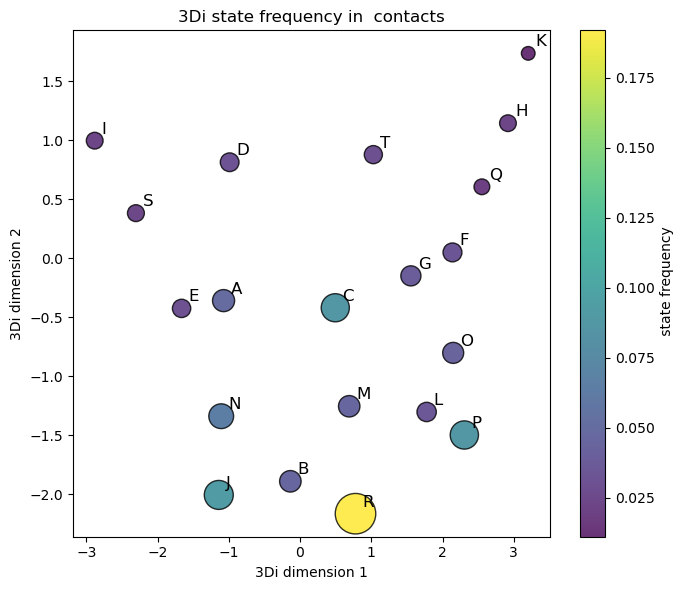

    state letter  frequency
0       0      A   0.048664
1       1      B   0.045539
2       2      C   0.086540
3       3      D   0.031610
4       4      E   0.029772
5       5      F   0.032503
6       6      G   0.038380
7       7      H   0.022738
8       8      I   0.022918
9       9      J   0.092523
10     10      K   0.011159
11     11      L   0.034594
12     12      M   0.045186
13     13      N   0.064437
14     14      O   0.042992
15     15      P   0.087309
16     16      Q   0.018829
17     17      R   0.191930
18     18      S   0.023466
19     19      T   0.028912


In [64]:
frequencies = plot_3Di_freq(df, centroids, state_to_letter)
print(frequencies)

In [ ]:

def compute_enrichment_table(df, centroids, state_to_letter, label = "HBOND"):


    # -----------------------------
    # 1. Non-bond state frequency
    # -----------------------------

    nonbond_states = (
        pd.concat([
            df.loc[df[label] == 0, "s_3di_state"],
            df.loc[df[label] == 0, "t_3di_state"]
        ])
        .dropna()
        .astype(int)
    )

    nonbond_counts = nonbond_states.value_counts().sort_index()
    nonbond_freq = nonbond_counts / nonbond_counts.sum()


    # -----------------------------
    # 2. Bond-conditioned frequency
    # -----------------------------

    bond_states = (
        pd.concat([
            df.loc[df[label] == 1, "s_3di_state"],
            df.loc[df[label] == 1, "t_3di_state"]
        ])
        .dropna()
        .astype(int)
    )

    bond_counts = bond_states.value_counts().sort_index()
    bond_freq = bond_counts / bond_counts.sum()


    # -----------------------------
    # 3. Enrichment table
    # -----------------------------

    states = np.arange(len(centroids))

    enrichment_df = pd.DataFrame({
        "state": states,
        "letter": [state_to_letter[i] for i in states],
        "nonbond_count": nonbond_counts.reindex(states, fill_value=0).values,
        "bond_count": bond_counts.reindex(states, fill_value=0).values,
        "nonbond_frequency": nonbond_freq.reindex(states, fill_value=0).values,
        "bond_frequency": bond_freq.reindex(states, fill_value=0).values
    })

    enrichment_df["frequency_difference"] = (
        enrichment_df["bond_frequency"]
        - enrichment_df["nonbond_frequency"]
    )

    enrichment_df["fold_enrichment"] = (
        enrichment_df["bond_frequency"]
        / enrichment_df["nonbond_frequency"]
    )


    enrichment_df["log2_fold_enrichment"] = (
        np.log2(enrichment_df["fold_enrichment"])
    )


    enrichment_df = enrichment_df.sort_values(
        "log2_fold_enrichment",
        ascending=False
    )

    return enrichment_df

In [89]:
def plot_enrichment(
    df,
    centroids,
    state_to_letter,
    label,
    figsize=(7.2, 5.2),
    min_size=80,
    max_size=650,
    cmap="coolwarm",
    save_path=None,
    dpi=300
):
    """
    Plot 3Di state enrichment in a contact class relative to non-class contacts.

    Color: log2 fold enrichment.
    Size: frequency of the state within the contact class.
    """

    enrichment_plot_df = compute_enrichment_table(
        df,
        centroids,
        state_to_letter,
        label
    ).copy()

    # Add centroid coordinates
    centroid_coord_df = pd.DataFrame({
        "state": np.arange(len(centroids)),
        "x": centroids[:, 0],
        "y": centroids[:, 1]
    })

    enrichment_plot_df = enrichment_plot_df.merge(
        centroid_coord_df,
        on="state",
        how="left"
    )

    # Clean enrichment values
    enrichment_plot_df["log2_fold_enrichment"] = (
        enrichment_plot_df["log2_fold_enrichment"]
        .replace([np.inf, -np.inf], np.nan)
    )

    # Symmetric color scale around zero
    color_abs_max = np.nanmax(
        np.abs(enrichment_plot_df["log2_fold_enrichment"])
    )

    if not np.isfinite(color_abs_max) or color_abs_max == 0:
        color_abs_max = 1

    # Scale dot size by within-class frequency
    max_freq = enrichment_plot_df["bond_frequency"].max()

    if max_freq == 0:
        enrichment_plot_df["marker_size"] = min_size
    else:
        enrichment_plot_df["marker_size"] = (
            min_size
            + (
                enrichment_plot_df["bond_frequency"]
                / max_freq
            )
            * (max_size - min_size)
        )

    fig, ax = plt.subplots(figsize=figsize)

    scatter = ax.scatter(
        enrichment_plot_df["x"],
        enrichment_plot_df["y"],
        c=enrichment_plot_df["log2_fold_enrichment"],
        s=enrichment_plot_df["marker_size"],
        cmap=cmap,
        vmin=-color_abs_max,
        vmax=color_abs_max,
        alpha=0.9,
        edgecolor="black",
        linewidth=0.6
    )

    # State labels
    for _, row in enrichment_plot_df.iterrows():

        ax.annotate(
            row["letter"],
            xy=(row["x"], row["y"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
            ha="left",
            va="bottom"
        )

    # Reference axes
    ax.axhline(0, color="0.85", linewidth=0.8, zorder=0)
    ax.axvline(0, color="0.85", linewidth=0.8, zorder=0)

    # Colorbar
    cbar = fig.colorbar(
        scatter,
        ax=ax,
        fraction=0.045,
        pad=0.04,
        shrink=0.7
    )

    cbar.set_label(
        r"log$_2$ fold enrichment",
        fontsize=10
    )

    cbar.ax.tick_params(labelsize=9)

    ax.set_xlabel("3Di dimension 1", fontsize=11)
    ax.set_ylabel("3Di dimension 2", fontsize=11)

    ax.set_title(
        f"{label} enrichment across 3Di states",
        fontsize=13,
        pad=10
    )

    ax.tick_params(axis="both", labelsize=9)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_aspect("equal", adjustable="box")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

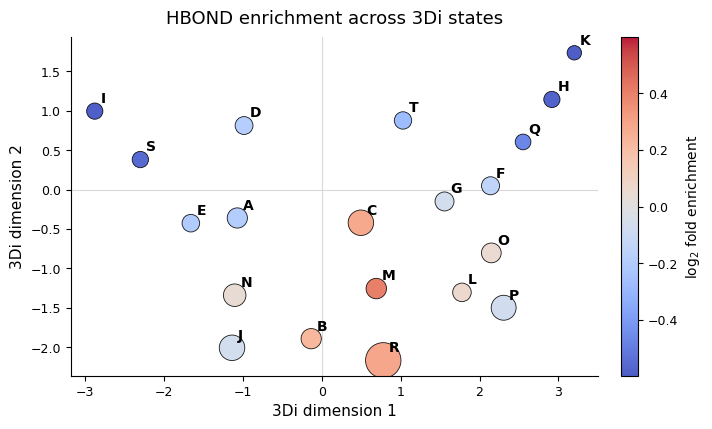

In [90]:
plot_enrichment(
    df=df,
    centroids=centroids,
    state_to_letter=state_to_letter,
    label="HBOND",
    save_path="report_figures/hbond_3di_enrichment.png"
)

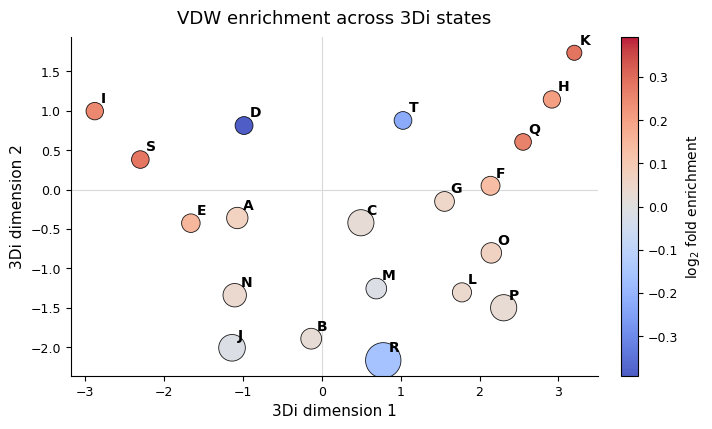

In [91]:
plot_enrichment(
    df=df,
    centroids=centroids,
    state_to_letter=state_to_letter,
    label="VDW",
    save_path="report_figures/vdw_3di_enrichment.png"
)

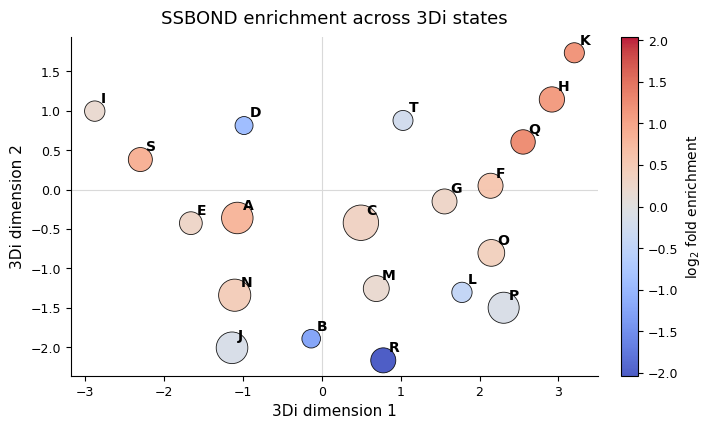

In [93]:
plot_enrichment(
    df=df,
    centroids=centroids,
    state_to_letter=state_to_letter,
    label="SSBOND",
    save_path="report_figures/ssbond_3di_enrichment.png"
)